bucket
0    0.000760
1    0.000721
2    0.000622
3    0.000591
4    0.000686
5    0.000857
6    0.000855
7    0.001002
8    0.000866
9    0.000941
Name: next_return, dtype: float64


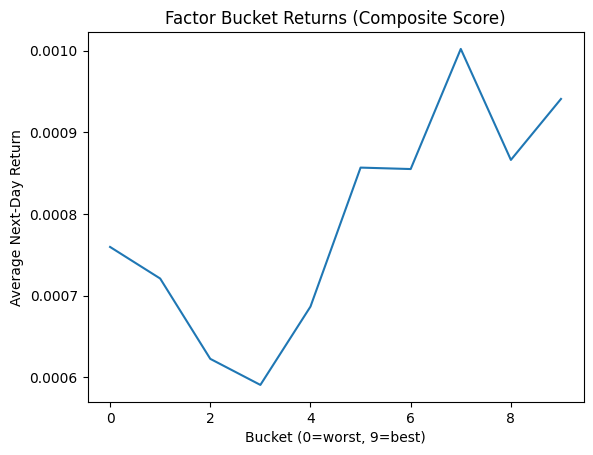

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

signals = pd.read_parquet("data/signals.parquet")
market = pd.read_parquet("data/market_data.parquet")

# merge signals with next-day returns
market = market.sort_values(["symbol", "date"])
market["next_return"] = market.groupby("symbol")["close"].pct_change().shift(-1)

df = signals.merge(
    market[["date", "symbol", "next_return"]],
    on=["date", "symbol"],
    how="left"
)

df = df.dropna(subset=["composite_score", "next_return"])

# create rank buckets
df["bucket"] = pd.qcut(df["composite_score"], 10, labels=False)

bucket_returns = df.groupby("bucket")["next_return"].mean()
print(bucket_returns)

plt.plot(bucket_returns)
plt.title("Factor Bucket Returns (Composite Score)")
plt.xlabel("Bucket (0=worst, 9=best)")
plt.ylabel("Average Next-Day Return")
plt.show()

In [3]:
print("Top - Bottom Spread:", bucket_returns.iloc[-1] - bucket_returns.iloc[0])

Top - Bottom Spread: 0.0001812754926204705


Horizon: 1 day(s)
Mean IC:        0.011476
IC Std Dev:     0.119594
IC IR:          0.095957
Positive IC %:  55.46%
Num days:       1109

IC quantiles:
0.01   -0.298662
0.05   -0.196591
0.25   -0.061242
0.50    0.015071
0.75    0.086608
0.95    0.203161
0.99    0.296003
Name: ic, dtype: float64


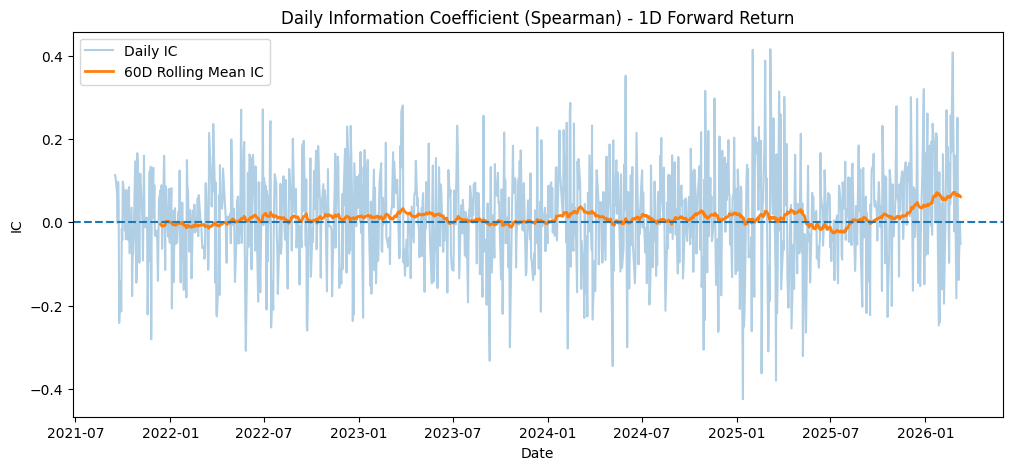

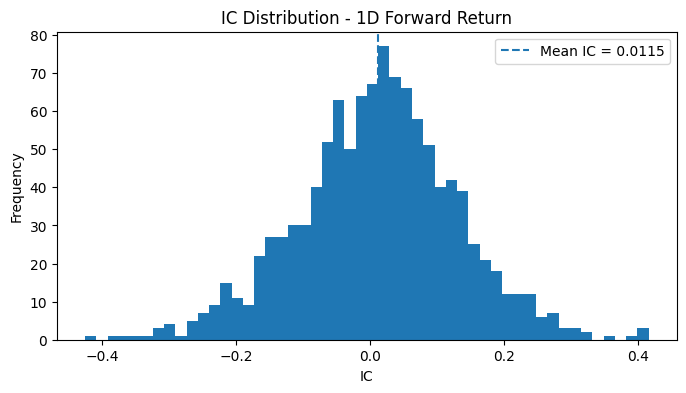

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load data
# -----------------------------
signals = pd.read_parquet("data/signals.parquet")
market = pd.read_parquet("data/market_data.parquet")

signals["date"] = pd.to_datetime(signals["date"])
market["date"] = pd.to_datetime(market["date"])

# -----------------------------
# Build forward returns
# Change horizon here if needed
# horizon = 1, 5, 10, 20 ...
# -----------------------------
horizon = 1

market = market.sort_values(["symbol", "date"]).copy()
market[f"fwd_return_{horizon}d"] = (
    market.groupby("symbol")["close"].shift(-horizon) / market["close"] - 1.0
)

# -----------------------------
# Merge factor + forward returns
# -----------------------------
df = signals.merge(
    market[["date", "symbol", f"fwd_return_{horizon}d"]],
    on=["date", "symbol"],
    how="left",
)

df = df.dropna(subset=["composite_score", f"fwd_return_{horizon}d"]).copy()

# keep only valid cross-sections with enough names
min_names_per_day = 20
counts = df.groupby("date")["symbol"].count()
valid_dates = counts[counts >= min_names_per_day].index
df = df[df["date"].isin(valid_dates)].copy()

# -----------------------------
# Daily IC
# Spearman rank correlation is standard for factor research
# -----------------------------
ic_by_day = (
    df.groupby("date")
    .apply(lambda x: x["composite_score"].corr(x[f"fwd_return_{horizon}d"], method="spearman"))
    .dropna()
    .rename("ic")
    .reset_index()
)

# -----------------------------
# Summary stats
# -----------------------------
mean_ic = ic_by_day["ic"].mean()
std_ic = ic_by_day["ic"].std(ddof=1)
ic_ir = mean_ic / std_ic if std_ic > 0 else np.nan
positive_rate = (ic_by_day["ic"] > 0).mean()

print(f"Horizon: {horizon} day(s)")
print(f"Mean IC:        {mean_ic:.6f}")
print(f"IC Std Dev:     {std_ic:.6f}")
print(f"IC IR:          {ic_ir:.6f}")
print(f"Positive IC %:  {positive_rate:.2%}")
print(f"Num days:       {len(ic_by_day)}")

print("\nIC quantiles:")
print(ic_by_day["ic"].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))

# -----------------------------
# Rolling IC plot
# -----------------------------
rolling_window = 60
ic_by_day["rolling_ic"] = ic_by_day["ic"].rolling(rolling_window).mean()

plt.figure(figsize=(12, 5))
plt.plot(ic_by_day["date"], ic_by_day["ic"], alpha=0.35, label="Daily IC")
plt.plot(ic_by_day["date"], ic_by_day["rolling_ic"], linewidth=2, label=f"{rolling_window}D Rolling Mean IC")
plt.axhline(0.0, linestyle="--")
plt.title(f"Daily Information Coefficient (Spearman) - {horizon}D Forward Return")
plt.xlabel("Date")
plt.ylabel("IC")
plt.legend()
plt.show()

# -----------------------------
# IC histogram
# -----------------------------
plt.figure(figsize=(8, 4))
plt.hist(ic_by_day["ic"], bins=50)
plt.axvline(mean_ic, linestyle="--", label=f"Mean IC = {mean_ic:.4f}")
plt.title(f"IC Distribution - {horizon}D Forward Return")
plt.xlabel("IC")
plt.ylabel("Frequency")
plt.legend()
plt.show()

   horizon_days   mean_ic    std_ic     ic_ir  positive_ic_pct
0             1  0.011476  0.119594  0.095957         0.554554
1             5  0.017425  0.127127  0.137063         0.576471
2            10  0.019684  0.124996  0.157477         0.559091
3            20  0.020458  0.123150  0.166123         0.597248


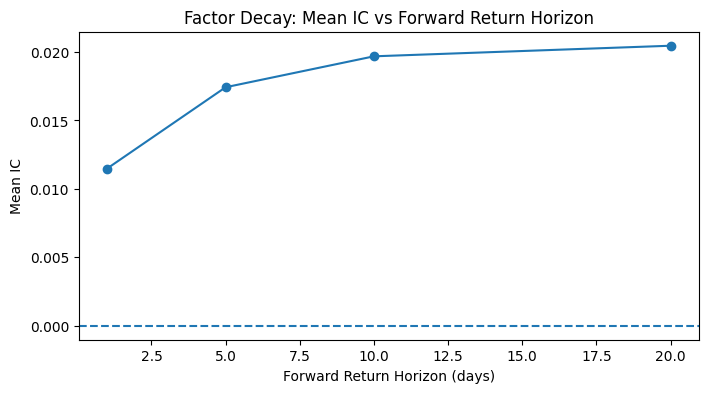

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

signals = pd.read_parquet("data/signals.parquet")
market = pd.read_parquet("data/market_data.parquet")

signals["date"] = pd.to_datetime(signals["date"])
market["date"] = pd.to_datetime(market["date"])
market = market.sort_values(["symbol", "date"]).copy()

horizons = [1, 5, 10, 20]
results = []

for horizon in horizons:
    temp = market.copy()
    temp[f"fwd_return_{horizon}d"] = (
        temp.groupby("symbol")["close"].shift(-horizon) / temp["close"] - 1.0
    )

    df = signals.merge(
        temp[["date", "symbol", f"fwd_return_{horizon}d"]],
        on=["date", "symbol"],
        how="left",
    )

    df = df.dropna(subset=["composite_score", f"fwd_return_{horizon}d"]).copy()

    ic_by_day = (
        df.groupby("date")
        .apply(lambda x: x["composite_score"].corr(x[f"fwd_return_{horizon}d"], method="spearman"))
        .dropna()
    )

    mean_ic = ic_by_day.mean()
    std_ic = ic_by_day.std(ddof=1)
    ic_ir = mean_ic / std_ic if std_ic > 0 else np.nan
    positive_rate = (ic_by_day > 0).mean()

    results.append(
        {
            "horizon_days": horizon,
            "mean_ic": mean_ic,
            "std_ic": std_ic,
            "ic_ir": ic_ir,
            "positive_ic_pct": positive_rate,
        }
    )

results_df = pd.DataFrame(results)
print(results_df)

plt.figure(figsize=(8, 4))
plt.plot(results_df["horizon_days"], results_df["mean_ic"], marker="o")
plt.axhline(0.0, linestyle="--")
plt.title("Factor Decay: Mean IC vs Forward Return Horizon")
plt.xlabel("Forward Return Horizon (days)")
plt.ylabel("Mean IC")
plt.show()

Mean daily return: 0.00013070473178604917
Volatility: 0.008685212947920908
Sharpe: 0.23889722743164302


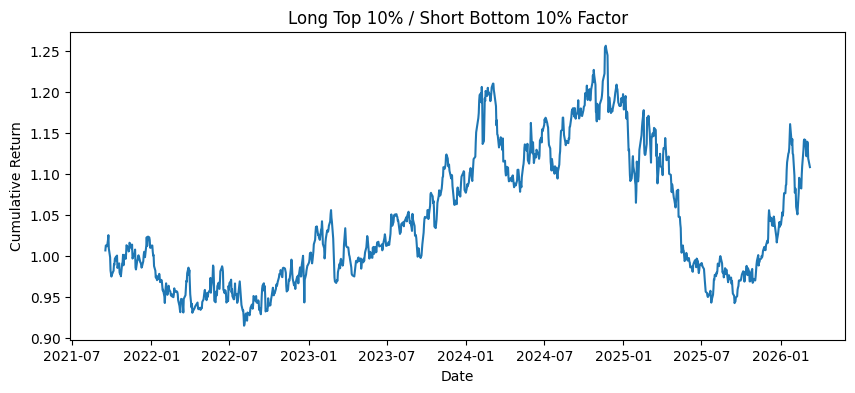

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

signals = pd.read_parquet("data/signals.parquet")
market = pd.read_parquet("data/market_data.parquet")

signals["date"] = pd.to_datetime(signals["date"])
market["date"] = pd.to_datetime(market["date"])

# build forward return
market = market.sort_values(["symbol","date"])
market["next_return"] = market.groupby("symbol")["close"].pct_change().shift(-1)

df = signals.merge(
    market[["date","symbol","next_return"]],
    on=["date","symbol"],
    how="left"
)

df = df.dropna(subset=["composite_score","next_return"])

# rank cross-sectionally each day
df["rank"] = df.groupby("date")["composite_score"].rank(pct=True)

# define long / short groups
long_mask = df["rank"] >= 0.9
short_mask = df["rank"] <= 0.1

# compute daily returns
long_returns = df[long_mask].groupby("date")["next_return"].mean()
short_returns = df[short_mask].groupby("date")["next_return"].mean()

factor_returns = long_returns - short_returns

factor_returns = factor_returns.dropna()

# cumulative return
equity_curve = (1 + factor_returns).cumprod()

print("Mean daily return:", factor_returns.mean())
print("Volatility:", factor_returns.std())
print("Sharpe:", factor_returns.mean()/factor_returns.std()*np.sqrt(252))

plt.figure(figsize=(10,4))
plt.plot(equity_curve)
plt.title("Long Top 10% / Short Bottom 10% Factor")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.show()

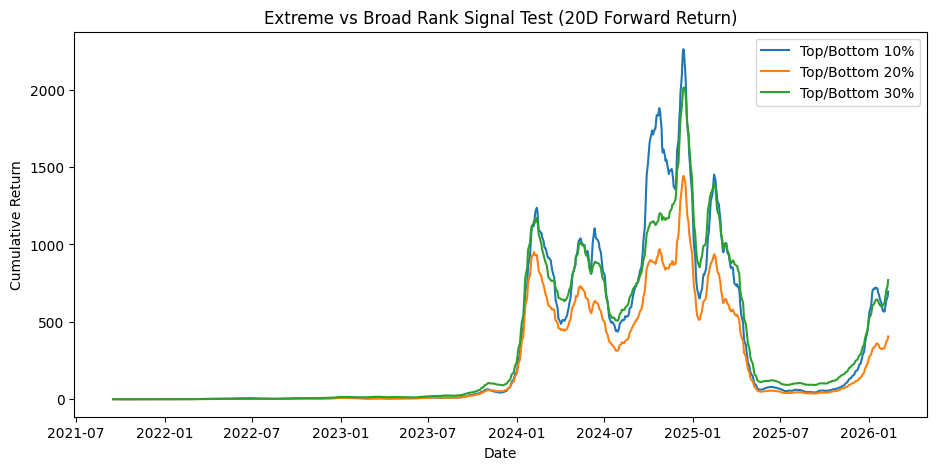

             band  mean_return  volatility  sharpe_no_annual  num_days
0  top/bottom 10%     0.006770    0.038711          0.174882      1090
1  top/bottom 20%     0.006049    0.032365          0.186894      1090
2  top/bottom 30%     0.006501    0.027761          0.234180      1090


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

signals = pd.read_parquet("data/signals.parquet")
market = pd.read_parquet("data/market_data.parquet")

signals["date"] = pd.to_datetime(signals["date"])
market["date"] = pd.to_datetime(market["date"])

# ---------- choose horizon ----------
horizon = 20  # try 1, 5, 10, 20

market = market.sort_values(["symbol", "date"]).copy()
market[f"fwd_return_{horizon}d"] = (
    market.groupby("symbol")["close"].shift(-horizon) / market["close"] - 1.0
)

df = signals.merge(
    market[["date", "symbol", f"fwd_return_{horizon}d"]],
    on=["date", "symbol"],
    how="left",
)

df = df.dropna(subset=["composite_score", f"fwd_return_{horizon}d"]).copy()

# use percentile ranks within each date
df["rank_pct"] = df.groupby("date")["composite_score"].rank(pct=True)

bands = [0.10, 0.20, 0.30]
results = []

plt.figure(figsize=(11, 5))

for band in bands:
    long_mask = df["rank_pct"] >= (1.0 - band)
    short_mask = df["rank_pct"] <= band

    long_ret = (
        df.loc[long_mask]
        .groupby("date")[f"fwd_return_{horizon}d"]
        .mean()
    )

    short_ret = (
        df.loc[short_mask]
        .groupby("date")[f"fwd_return_{horizon}d"]
        .mean()
    )

    spread = (long_ret - short_ret).dropna().sort_index()

    mean_ret = spread.mean()
    vol = spread.std(ddof=1)
    sharpe = mean_ret / vol if vol > 0 else np.nan

    results.append({
        "band": f"top/bottom {int(band*100)}%",
        "mean_return": mean_ret,
        "volatility": vol,
        "sharpe_no_annual": sharpe,
        "num_days": len(spread),
    })

    equity = (1.0 + spread).cumprod()
    plt.plot(equity.index, equity.values, label=f"Top/Bottom {int(band*100)}%")

plt.title(f"Extreme vs Broad Rank Signal Test ({horizon}D Forward Return)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.show()

results_df = pd.DataFrame(results)
print(results_df)